In [ ]:
from __future__ import print_function
from __future__ import division
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
print("PyTorch Version: ",torch.__version__)
print("Torchvision Version: ",torchvision.__version__)

PyTorch Version:  2.9.0+cu126
Torchvision Version:  0.24.0+cu126


In [ ]:
 #Link Google Drive with Colab to Access Data

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# define training and test data directories

data_dir = '/path/to/dataset/'
train_dir = os.path.join(data_dir, 'train/')
valid_dir = os.path.join(data_dir, 'val/')
#test_dir = os.path.join(data_dir, 'test/')

# classes are folders in each directory with these names
classes = ['aedes', 'anopheles', 'cimex', 'ctenocephalides', 'culex', 'pediculus', 'triatoma' ]

In [ ]:
model_name = "inception"

# Number of classes in the dataset
num_classes = 7

# Batch size for training (change depending on how much memory you have)
batch_size = 16

# Number of epochs to train for
num_epochs = 30

# Flag for feature extracting. When False, we finetune the whole model,
#   when True we only update the reshaped layer params
feature_extract = False

In [ ]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=30, is_inception=False):
    since = time.time()

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []


    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    # Get model outputs and calculate loss
                    # Special case for inception because in training it has an auxiliary output. In train
                    #   mode we calculate the loss by summing the final output and the auxiliary output
                    #   but in testing we only consider the final output.
                    if is_inception and phase == 'train':
                        # From https://discuss.pytorch.org/t/how-to-optimize-inception-model-with-auxiliary-classifiers/7958
                        outputs, aux_outputs = model(inputs)
                        loss1 = criterion(outputs, labels)
                        loss2 = criterion(aux_outputs, labels)
                        loss = loss1 + 0.4*loss2
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))


            # Save history once per epoch
            if phase == 'train':
               train_loss_history.append(epoch_loss)
               train_acc_history.append(epoch_acc.cpu().item())
            else:  # phase == 'val'
               val_loss_history.append(epoch_loss)
               val_acc_history.append(epoch_acc.cpu().item())

               # update LR scheduler
               lr_scheduler.step(epoch_acc)

           # deep copy best weights
            if phase == 'val' and epoch_acc > best_acc:
               best_acc = epoch_acc
               best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, train_loss_history, val_loss_history, train_acc_history, val_acc_history

In [ ]:
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

In [ ]:
def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    model_ft = None
    input_size = 0

    if model_name == "inception":
        from torchvision.models import inception_v3, Inception_V3_Weights

        weights = Inception_V3_Weights.DEFAULT if use_pretrained else None

        model_ft = inception_v3(
            weights=weights,
            aux_logits=True
        )

        # Freeze layers if feature_extract=True
        set_parameter_requires_grad(model_ft, feature_extract)

        # Auxiliary classifier
        aux_ftrs = model_ft.AuxLogits.fc.in_features
        model_ft.AuxLogits.fc = nn.Linear(aux_ftrs, num_classes)

        # Main classifier
        main_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(main_ftrs, num_classes)

        input_size = 299

    return model_ft, input_size

In [ ]:
# Initialize the model for this run
model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

# Print the model we just instantiated
print(model_ft)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 169MB/s]


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [ ]:
print("Model name is:", model_name)

Model name is: inception


In [ ]:
class_counts = torch.tensor(
    [2250, 2250, 1187, 2250, 2250, 532, 2250], dtype=torch.float)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()


In [ ]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(input_size, scale=(0.6, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(25),
        transforms.RandomPerspective(distortion_scale=0.3, p=0.3),
        transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.4, hue=0.03),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])



    ]),

    'val': transforms.Compose([
        transforms.Resize(input_size),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

print("Initializing Datasets and Dataloaders...")


Initializing Datasets and Dataloaders...


In [ ]:

# Create training and validation datasets
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}

from torch.utils.data import WeightedRandomSampler

targets = [label for _, label in image_datasets['train']]
sample_weights = [class_weights[label].item() for label in targets]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = torch.utils.data.DataLoader(
    image_datasets['train'],
    batch_size=batch_size,
    sampler=sampler,
    num_workers=4
)

val_loader = torch.utils.data.DataLoader(
    image_datasets['val'],
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

dataloaders_dict = {"train": train_loader, "val": val_loader}



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
# Send the model to GPU
model_ft = model_ft.to(device)

# Gather the parameters to be optimized/updated in this run. If we are
#  finetuning we will be updating all parameters. However, if we are
#  doing feature extract method, we will only update the parameters
#  that we have just initialized, i.e. the parameters with requires_grad
#  is True.
params_to_update = model_ft.parameters()
print("Params to learn:")
if feature_extract:
    params_to_update = []
    for name,param in model_ft.named_parameters():
        if param.requires_grad == True:
            params_to_update.append(param)
            print("\t",name)
else:
    for name,param in model_ft.named_parameters():
        if param.requires_grad == True:
            print("\t",name)

# Observe that all parameters are being optimized
optimizer_ft = optim.AdamW(params_to_update, lr=3e-5, weight_decay=1e-4)

lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode='max',
    factor=0.3,
    patience=3
)


Params to learn:
	 Conv2d_1a_3x3.conv.weight
	 Conv2d_1a_3x3.bn.weight
	 Conv2d_1a_3x3.bn.bias
	 Conv2d_2a_3x3.conv.weight
	 Conv2d_2a_3x3.bn.weight
	 Conv2d_2a_3x3.bn.bias
	 Conv2d_2b_3x3.conv.weight
	 Conv2d_2b_3x3.bn.weight
	 Conv2d_2b_3x3.bn.bias
	 Conv2d_3b_1x1.conv.weight
	 Conv2d_3b_1x1.bn.weight
	 Conv2d_3b_1x1.bn.bias
	 Conv2d_4a_3x3.conv.weight
	 Conv2d_4a_3x3.bn.weight
	 Conv2d_4a_3x3.bn.bias
	 Mixed_5b.branch1x1.conv.weight
	 Mixed_5b.branch1x1.bn.weight
	 Mixed_5b.branch1x1.bn.bias
	 Mixed_5b.branch5x5_1.conv.weight
	 Mixed_5b.branch5x5_1.bn.weight
	 Mixed_5b.branch5x5_1.bn.bias
	 Mixed_5b.branch5x5_2.conv.weight
	 Mixed_5b.branch5x5_2.bn.weight
	 Mixed_5b.branch5x5_2.bn.bias
	 Mixed_5b.branch3x3dbl_1.conv.weight
	 Mixed_5b.branch3x3dbl_1.bn.weight
	 Mixed_5b.branch3x3dbl_1.bn.bias
	 Mixed_5b.branch3x3dbl_2.conv.weight
	 Mixed_5b.branch3x3dbl_2.bn.weight
	 Mixed_5b.branch3x3dbl_2.bn.bias
	 Mixed_5b.branch3x3dbl_3.conv.weight
	 Mixed_5b.branch3x3dbl_3.bn.weight
	 Mixed_5b.b

In [ ]:
# Setup the loss fxn
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))


# Train and evaluate
model_ft, train_loss, val_loss, train_acc, val_acc = train_model(
    model_ft, dataloaders_dict, criterion, optimizer_ft,
    num_epochs=num_epochs, is_inception=(model_name=="inception")
)

Epoch 0/29
----------
train Loss: 0.2481 Acc: 0.9179
val Loss: 0.1646 Acc: 0.9439

Epoch 1/29
----------
train Loss: 0.1905 Acc: 0.9399
val Loss: 0.1552 Acc: 0.9428

Epoch 2/29
----------
train Loss: 0.1470 Acc: 0.9476
val Loss: 0.1141 Acc: 0.9562

Epoch 3/29
----------
train Loss: 0.1323 Acc: 0.9544
val Loss: 0.1127 Acc: 0.9593

Epoch 4/29
----------
train Loss: 0.1167 Acc: 0.9627
val Loss: 0.1003 Acc: 0.9624

Epoch 5/29
----------
train Loss: 0.1000 Acc: 0.9679
val Loss: 0.1026 Acc: 0.9619

Epoch 6/29
----------
train Loss: 0.0877 Acc: 0.9718
val Loss: 0.0956 Acc: 0.9665

Epoch 7/29
----------
train Loss: 0.0785 Acc: 0.9740
val Loss: 0.0980 Acc: 0.9640

Epoch 8/29
----------
train Loss: 0.0709 Acc: 0.9777
val Loss: 0.1000 Acc: 0.9650

Epoch 9/29
----------
train Loss: 0.0744 Acc: 0.9756
val Loss: 0.0784 Acc: 0.9727

Epoch 10/29
----------
train Loss: 0.0654 Acc: 0.9777
val Loss: 0.0882 Acc: 0.9706

Epoch 11/29
----------
train Loss: 0.0643 Acc: 0.9811
val Loss: 0.0735 Acc: 0.9737

Ep

In [ ]:
print("train_loss =", train_loss)
print("val_loss =", val_loss)
print("train_acc =", train_acc)
print("val_acc =", val_acc)


train_loss = [0.24814620523736783, 0.19050857034627525, 0.14696050256231727, 0.13228173717363034, 0.11665814860748806, 0.09998464841527155, 0.08770725902031848, 0.07848902546896254, 0.07090521208673942, 0.07437134466312573, 0.0654104858216424, 0.064331342464434, 0.053275144719015205, 0.04478958304483821, 0.04874996568011056, 0.041142846789733914, 0.04511422912662224, 0.04146509877560854, 0.033604617747221566, 0.023808685465288734, 0.020287457238940147, 0.025752516311729912, 0.020331571674208584, 0.01848439380096071, 0.019377844654943188, 0.019782391716550433, 0.01719253888717793, 0.0145133785494598, 0.01866172357549322, 0.016253667558979695]
val_loss = [0.16462421271039784, 0.15523367295311197, 0.11408199450199183, 0.11273092731109789, 0.10026546631790803, 0.10260231903374475, 0.09559691220652729, 0.0979926433485197, 0.10002848705708219, 0.07842368336041376, 0.08820154502045269, 0.0735018041471961, 0.08571156489859419, 0.09025012015783608, 0.06841124189505357, 0.0740015968563277, 0.072

In [ ]:
def plot_training_curves(train_loss, val_loss, train_acc, val_acc):
    # Convert tensors to floats if needed
    train_loss = [t.cpu().item() if torch.is_tensor(t) else t for t in train_loss]
    val_loss   = [t.cpu().item() if torch.is_tensor(t) else t for t in val_loss]
    train_acc  = [t.cpu().item() if torch.is_tensor(t) else t for t in train_acc]
    val_acc    = [t.cpu().item() if torch.is_tensor(t) else t for t in val_acc]

    epochs = range(len(train_loss))

    plt.figure(figsize=(14,6))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

In [ ]:
print("train_loss:", len(train_loss))
print("val_loss:", len(val_loss))
print("train_acc:", len(train_acc))
print("val_acc:", len(val_acc))


train_loss: 30
val_loss: 30
train_acc: 30
val_acc: 30


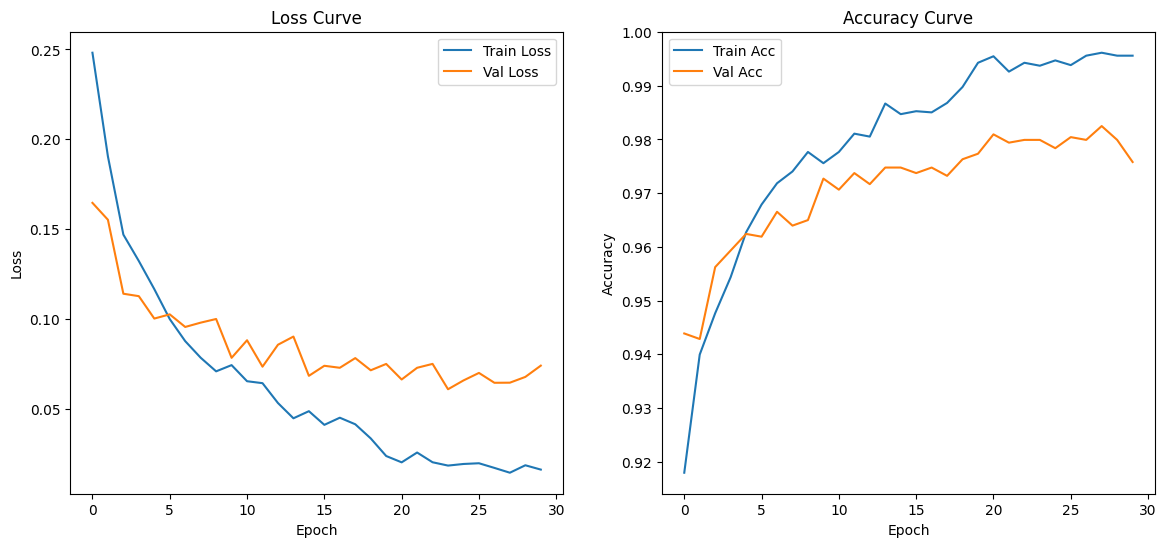

In [ ]:
plot_training_curves(train_loss, val_loss, train_acc, val_acc)

In [ ]:
test_dir = os.path.join(data_dir, "test")

test_dataset = datasets.ImageFolder(
    test_dir,
    data_transforms['val']     # Use validation transforms
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def evaluate_on_test(model, test_loader):
    model.eval()
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    preds_list = np.array(preds_list)
    labels_list = np.array(labels_list)
    return preds_list, labels_list


In [ ]:
y_pred, y_true = evaluate_on_test(model_ft, test_loader)


In [ ]:
test_accuracy = np.mean(y_pred == y_true)
print("Test Accuracy: {:.4f}".format(test_accuracy))

Test Accuracy: 0.9805


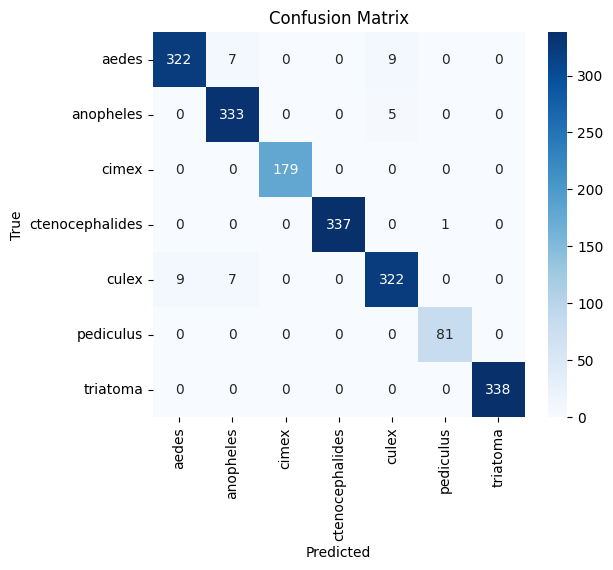

                 precision    recall  f1-score   support

          aedes       0.97      0.95      0.96       338
      anopheles       0.96      0.99      0.97       338
          cimex       1.00      1.00      1.00       179
ctenocephalides       1.00      1.00      1.00       338
          culex       0.96      0.95      0.96       338
      pediculus       0.99      1.00      0.99        81
       triatoma       1.00      1.00      1.00       338

       accuracy                           0.98      1950
      macro avg       0.98      0.98      0.98      1950
   weighted avg       0.98      0.98      0.98      1950



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Per-Class Precision, Recall, F1
print(classification_report(y_true, y_pred, target_names=classes))


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve

model_ft.eval()
all_probs = []

with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model_ft(inputs)
        all_probs.append(torch.softmax(outputs, dim=1).cpu().numpy())

all_probs = np.vstack(all_probs)  # [N, 7]
y_true_bin = label_binarize(y_true, classes=list(range(7)))


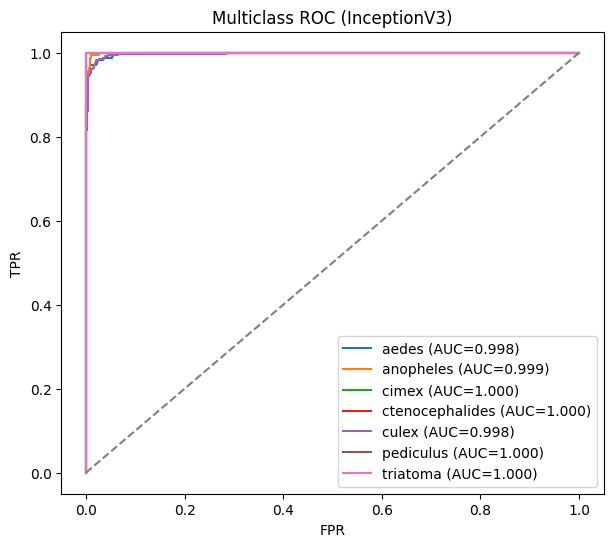

In [ ]:
plt.figure(figsize=(7,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC (InceptionV3)")
plt.legend()
plt.show()



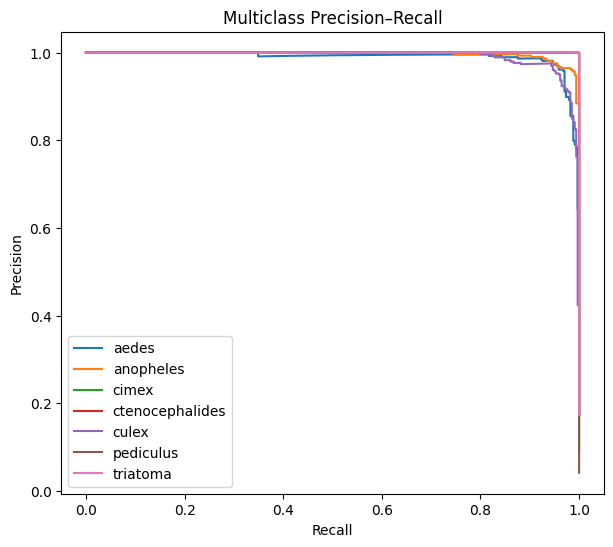

In [ ]:
plt.figure(figsize=(7,6))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], all_probs[:, i])
    plt.plot(recall, precision, label=cls)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multiclass Precision–Recall")
plt.legend()
plt.show()



In [ ]:
torch.save(
    model_ft.state_dict(),
    "/content/drive/MyDrive/Insects/Models/best_inception.pth"
)

In [ ]:
model_ft.load_state_dict(torch.load("/content/drive/MyDrive/Insects/Models/best_inception.pth"))
model_ft.eval()


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri